In [40]:
import numpy as pd
import pandas as pd
import os 

In [41]:
df = pd.read_csv('iris.csv')

In [42]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [43]:
df = df.iloc[:,1:]

In [44]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [45]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [46]:
df['Species'] = encoder.fit_transform(df['Species'])

In [47]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [48]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [49]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

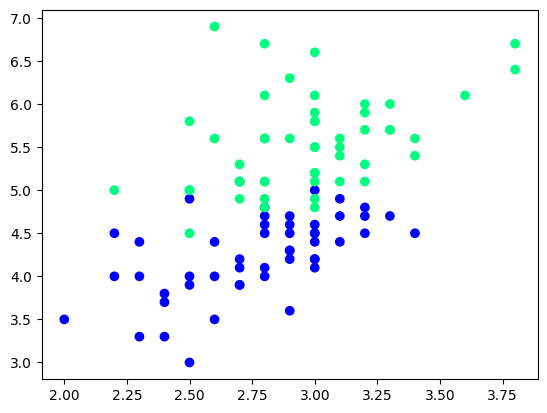

In [51]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap = 'winter')

In [52]:
# Takjing only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [53]:
df_train


,SepalWidthCm,PetalLengthCm,Species
52,3.1,4.9,1
117,3.8,6.7,2
115,3.2,5.3,2
118,2.6,6.9,2
88,3.0,4.1,1
124,3.3,5.7,2
106,2.5,4.5,2
80,2.4,3.8,1
126,2.8,4.8,2
77,3.0,5.0,1


In [54]:
df_val

,SepalWidthCm,PetalLengthCm,Species
145,3.0,5.2,2
125,3.2,6.0,2
81,2.4,3.7,1
127,3.0,4.9,2
73,2.8,4.7,1


In [55]:
df_test

,SepalWidthCm,PetalLengthCm,Species
101,2.7,5.1,2
75,3.0,4.4,1
110,3.2,5.1,2
54,2.8,4.6,1
79,2.6,3.5,1


In [56]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

# Case 1 - Bagging

In [57]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X= df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
106,2.5,4.5,2
106,2.5,4.5,2
126,2.8,4.8,2
118,2.6,6.9,2
126,2.8,4.8,2
115,3.2,5.3,2
80,2.4,3.8,1
124,3.3,5.7,2


In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [59]:
df_bag1 = DecisionTreeClassifier()

In [60]:
def evaluate(clf, X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, clf = clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

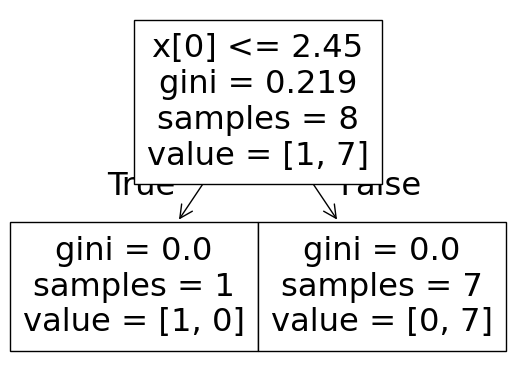

TypeError: plot_decision_regions() missing 1 required positional argument: 'y'

In [61]:
evaluate(df_bag1,X,y)